# CSA Provider examples

The [Cluster Science Archive (CSA)](https://csa.esac.esa.int/csa-web/) provides access to all science and support data from the Cluster (2000-present) and Double Star (2004-2008) missions.

## Only for Google Colab Users

In [1]:
%pip install --upgrade ipympl speasy

/home/jeandet/.cache/uv/builds-v0/.tmp7coj5y/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    print("Not running inside Google Collab")

Not running inside Google Collab


## For all users

In [3]:
import speasy as spz
%matplotlib inline
import matplotlib.pyplot as plt

Legacy cache backup already present at /home/jeandet/.cache/speasy/Cache.diskcache.backup; skipping auto-migration. Move or remove it to retry.


Legacy cache backup already present at /home/jeandet/.local/share/speasy/index.diskcache.backup; skipping auto-migration. Move or remove it to retry.


You are using an incompatible proxy server http://sciqlop.lpp.polytechnique.fr/cache which is 0.13.5 while minimun required version is 0.14.0


### Browse the inventory

Use tab-completion on `spz.inventories.data_tree.csa` (or `spz.inventories.tree.csa`) to find a product; the tree is organized by mission, spacecraft, instrument, then dataset.

In [4]:
spz.inventories.tree.csa.Cluster.Cluster_3.FGM3

<SpeasyIndex: FGM3>

### A simple vector product: Cluster 3 magnetic field (GSE, spin resolution)

In [5]:
c3_fgm_spin = spz.csa.get_data(
    spz.inventories.data_tree.csa.Cluster.Cluster_3.FGM3.C3_CP_FGM_SPIN.B_vec_xyz_gse__C3_CP_FGM_SPIN,
    "2018-01-01", "2018-01-01T01",
)
c3_fgm_spin

SpeasyVariable(
    Name: 'B_vec_xyz_gse__C3_CP_FGM_SPIN', 
    Time Range: 2018-01-01T00:00:03.743000000 - 2018-01-01T00:59:57.563000000
    Shape: (852, 3), 
    Unit: 'nT', 
    Columns: ['Bx', 'By', 'Bz'], 
    Meta: {
        CATDESC: 'Magnetic Field Vector, spin resolution in GSE', 
        UNITS: 'nT', 
        SI_conversion: '1.0E-9>T', 
        FILLVAL: [-1.0000000150474662e+30], 
        FIELDNAM: 'Magnetic Field Vector, spin resolution in GSE', 
        LABLAXIS: 'Mag Field', 
        VALIDMIN: [-65536.0], 
        VALIDMAX: [65536.0], 
        FORMAT: 'F10.3', 
        VAR_TYPE: 'data', 
        sig_digits: [10], 
        DEPEND_0: 'time_tags__C3_CP_FGM_SPIN', 
        ENTITY: 'Magnetic_Field', 
        PROPERTY: 'Vector', 
        FLUCTUATIONS: 'Waveform', 
        TENSOR_ORDER: [1], 
        COORDINATE_SYSTEM: 'GSE>Geocentric Solar Ecliptic', 
        REPRESENTATION_1: 'B_vec_xyz_gse__C3_CP_FGM_SPIN_REPRESENTATION_1', 
        QUALITY: [3], 
        DISPLAY_TYPE: 'time_se

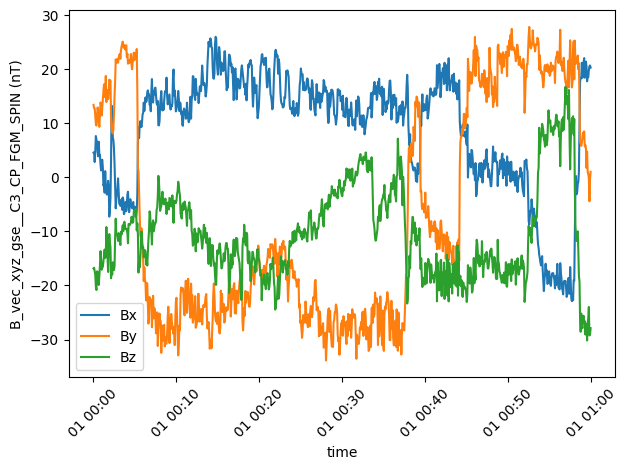

In [6]:
plt.figure()
c3_fgm_spin.plot()
plt.tight_layout()
plt.show()

### A spectrogram product: Cluster 1 CIS-HIA ion flux

This product's metadata marks it as a spectrogram (`DISPLAY_TYPE`), so `.plot()` automatically renders it as a colormap instead of a line plot:

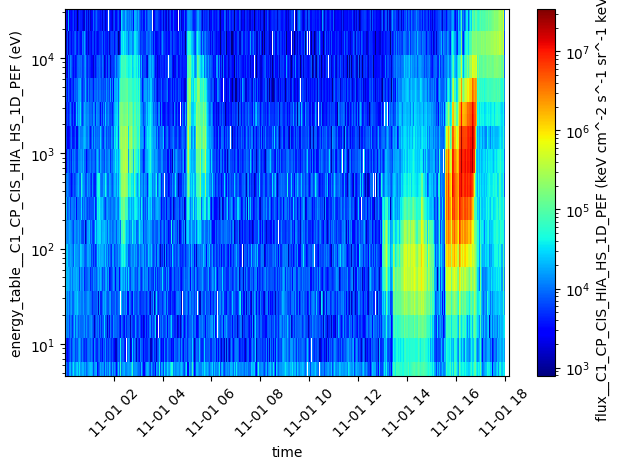

In [7]:
c1_cis_hia = spz.get_data(
    spz.inventories.tree.csa.Cluster.Cluster_1.CIS_HIA1.C1_CP_CIS_HIA_HS_1D_PEF.flux__C1_CP_CIS_HIA_HS_1D_PEF,
    "2006-11-01", "2006-11-02",
)
plt.figure()
c1_cis_hia.plot(cmap="jet")
plt.tight_layout()
plt.show()

### Note

CSA is a full mission archive integrated the same way as AMDA/CDAWeb/SSCWeb — see [Data Providers](../user/data_providers.rst) for cross-cutting notes on coordinate frames, time ranges, and units that apply here too.